In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!ls /content/drive/MyDrive/Intent-Classification-ML-Project

data  notebooks  README.md  requirements.txt  src


In [6]:
# Step 1: Point Colab to your project folder in Drive
%cd /content/drive/MyDrive/Intent-Classification-ML-Project/

# See what's inside the project
!ls

# See what files are in the data/ folder
!ls data

/content/drive/MyDrive/Intent-Classification-ML-Project
data  notebooks  README.md  requirements.txt  src
rba-dataset.csv


Logging Dataset Loading

In [7]:
import pandas as pd

# 🔁 Replace this with your actual CSV filename from the previous step
csv_path = "./data/rba-dataset.csv"

# Load a small sample first (e.g. 300k rows)
df_raw = pd.read_csv(csv_path, nrows=300000)

print("Shape:", df_raw.shape)

# See the column names
print("Columns:")
print(df_raw.columns.tolist())

# Look at first 5 rows as a table
df_raw.head()

Shape: (300000, 16)
Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover']


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


# EDA Steps

### Drop junk index col if present

In [8]:
df_raw[df_raw["Region"].isna()]


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
517,517,2020-02-03 12:51:02.563,-91826601905320326,NaN,10.0.57.183,NO,NaN,Østfold,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
2753,2753,2020-02-03 13:18:21.293,1965376449542060573,NaN,10.0.116.243,NO,NaN,NaN,500001,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.19,Mac OS X 10.14.6,desktop,True,False,False
3003,3003,2020-02-03 13:21:07.881,7045859536944212020,NaN,10.3.19.215,MW,NaN,NaN,507361,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.105,Mac OS X 10.14.6,desktop,True,False,False
7217,7217,2020-02-03 14:10:02.835,-5946097014299712769,NaN,10.3.95.161,NO,NaN,Oppegard,500167,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_8_4...,Chrome 86.0.4240.375,Mac OS X 10.8.4,desktop,True,False,False
10066,10066,2020-02-03 14:43:07.735,8488946108544163258,NaN,10.0.117.83,NO,NaN,NaN,207464,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile WebView 85.0.4183,iOS 13.4,mobile,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294485,294485,2020-02-07 10:00:54.396,-4324475583306591935,NaN,10.2.67.63,RO,NaN,NaN,500061,Mozilla/5.0 (Macintosh; Intel Mac OS X 11_6_3...,Chrome 80.0.3987.252.256,Mac OS X 11.6.3,desktop,False,False,False
295785,295785,2020-02-07 10:20:06.136,7045859536944212020,NaN,10.3.19.215,MW,NaN,NaN,507361,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.105,Mac OS X 10.14.6,desktop,True,False,False
296555,296555,2020-02-07 10:30:45.643,-303816097656981991,NaN,10.0.65.224,NO,NaN,Bo,29695,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,False,False,False
296628,296628,2020-02-07 10:31:44.635,-303816097656981991,NaN,10.0.65.224,NO,NaN,Bo,29695,Mozilla/5.0 (iPad; CPU OS 8_2 like Mac OS X) ...,Android 2.3.6,iOS 8.2,mobile,True,False,False


In [9]:
df = df_raw.copy()
df.drop(columns=['index'],inplace=True,errors='ignore')

### Checking Missing Values

In [10]:
# Missing value count per column (sorted)
missing_count = df_raw.isna().sum().sort_values(ascending=False)

# Show only columns that actually have missing values
missing_count[missing_count > 0]


,0
Round-Trip Time [ms],286788
Region,211
City,100
Device Type,14


### Handling Missing Values

In [11]:
df = df_raw.copy()
df["Round-Trip Time [ms]"] = pd.to_numeric(
    df["Round-Trip Time [ms]"], errors="coerce"
)

df["Round-Trip Time [ms]"] = df["Round-Trip Time [ms]"].fillna(
    df["Round-Trip Time [ms]"].median()
)

In [12]:
# df["region_was_missing"] = df["Region"].isna().astype(int)

In [13]:
# string cols: fill + normalize (important for rule checks)
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()

# optional safe-cast
df["ASN"] = df["ASN"].astype(str)


In [14]:
df["Login Timestamp"] = pd.to_datetime(df["Login Timestamp"])
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

df["Login Timestamp"].min(), df["Login Timestamp"].max()

(Timestamp('2020-02-03 12:43:30.772000'),
 Timestamp('2020-02-07 11:17:17.158000'))

In [15]:
# Normalize location + device
for col in ["Country", "Region", "City", "Device Type"]:
    df[col] = df[col].str.strip().str.lower()

# ASN as categorical
df["ASN"] = df["ASN"].astype(str)

# Simplify browser & OS
df["browser"] = df["Browser Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()
df["os"] = df["OS Name and Version"].str.extract(r"^([A-Za-z]+)")[0].str.lower()

In [16]:
df[["Browser Name and Version", "browser", "OS Name and Version", "os"]].head()

,Browser Name and Version,browser,OS Name and Version,os
0,Chrome 69.0.3497.17.19,chrome,Mac OS X 10.14.6,mac
1,Android 2.3.3.2672,android,iOS 7.1,ios
2,Android 2.3.3.2672,android,iOS 7.1,ios
3,Chrome Mobile 81.0.4044.2033,chrome,iOS 13.4,ios
4,Opera Mobile 52.1.2254,opera,Android 13.0,android


In [17]:
# df[df["browser"].isna()]

There no Empty Rows now for sample 20,000

In [18]:
df.isna().sum()
[df.isna().sum() > 0]

[index                       False
 Login Timestamp             False
 User ID                     False
 Round-Trip Time [ms]        False
 IP Address                  False
 Country                     False
 Region                      False
 City                        False
 ASN                         False
 User Agent String           False
 Browser Name and Version    False
 OS Name and Version         False
 Device Type                 False
 Login Successful            False
 Is Attack IP                False
 Is Account Takeover         False
 browser                      True
 os                           True
 dtype: bool]

In [19]:
# string cols: fill + normalize (important for rule checks)
for col in ["browser"]:
    df[col] = df[col].fillna("unknown").astype(str).str.strip().str.lower()

In [20]:
df.isna().sum()
[df.isna().sum() > 0]

[index                       False
 Login Timestamp             False
 User ID                     False
 Round-Trip Time [ms]        False
 IP Address                  False
 Country                     False
 Region                      False
 City                        False
 ASN                         False
 User Agent String           False
 Browser Name and Version    False
 OS Name and Version         False
 Device Type                 False
 Login Successful            False
 Is Attack IP                False
 Is Account Takeover         False
 browser                     False
 os                           True
 dtype: bool]

# 2. Data Quality

Shape + Columns + Dtypes

In [21]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

Shape: (300000, 18)

Columns:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover', 'browser', 'os']

Dtypes:
index                                int64
Login Timestamp             datetime64[ns]
User ID                              int64
Round-Trip Time [ms]               float64
IP Address                          object
Country                             object
Region                              object
City                                object
ASN                                 object
User Agent String                   object
Browser Name and Version            object
OS Name and Version                 object
Device Type                         object
Login Successful                      bool
Is Attack IP                          bool
Is Account Takeover                   b

Duplicate Checks (VERY small step)

We first check for full-row duplicates to identify data ingestion errors. We then check for logical duplicates using key identifiers such as user, timestamp, and IP, which represent a single login event. This helps avoid double-counting login attempts that differ only in metadata.

	•	User ID → who
	•	Login Timestamp → when
	•	IP Address → from where

In [22]:
# Full row duplicates
print("Duplicate full rows:", df.duplicated().sum())

# Duplicate login events (same user, same time, same IP)
key_cols = ["User ID", "Login Timestamp", "IP Address"]
print(
    "Duplicate key events:",
    df.duplicated(subset=key_cols).sum()
)

Duplicate full rows: 0
Duplicate key events: 0


Final Missing Values Check

In [23]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(3))

Columns with missing values:
os    14
dtype: int64

Missing percentage:
os    0.005
dtype: float64


# 3. Pattern Check

### Label distribution + base rate

In your 20,000-row sample, there are zero Account Takeover events.
So if we keep using Is Account Takeover right now:
	•	every chart will show 0 risk
	•	no “risk concentration” analysis is possible
	•	and later, a model can’t learn anything (no positive class)

So we are continue using Is Attack IP  - result is Positive rate: ~9.7%

In [24]:
label = "Is Attack IP"  # preferred
print("Using label:", label)

print("\nValue counts:")
print(df[label].value_counts())

print("\nPositive rate:")
print(df[label].mean())

Using label: Is Attack IP

Value counts:
Is Attack IP
False    272348
True      27652
Name: count, dtype: int64

Positive rate:
0.09217333333333333


Risk by Hour of Day


```
# Check whether risky logins cluster at certain hours.
```



hour
0     0.073578
1     0.146824
2     0.195648
3     0.191407
4     0.179715
5     0.160712
6     0.122327
7     0.104156
8     0.086157
9     0.085086
10    0.084813
11    0.086145
12    0.087766
13    0.091829
14    0.097852
15    0.106678
16    0.102129
17    0.083518
18    0.065542
19    0.057831
20    0.046403
21    0.034985
22    0.038179
23    0.058731
Name: Is Attack IP, dtype: float64


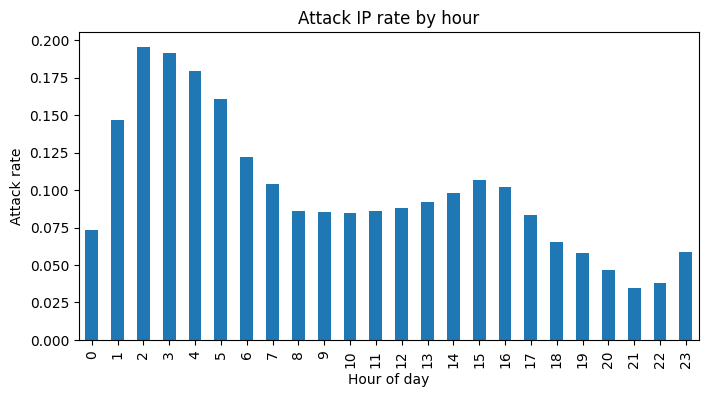

DA shows that attack IPs are significantly more likely during off-hours, so we include time-of-day as both a rule signal and an ML feature.


In [25]:
# We are using label=Is Attack Ip from above section
import matplotlib.pyplot as plt
df["hour"] = df["Login Timestamp"].dt.hour

hour_rate = df.groupby("hour")[label].mean()

print(hour_rate)

hour_rate.plot(kind="bar", figsize=(8,4))
plt.title("Attack IP rate by hour")
plt.xlabel("Hour of day")
plt.ylabel("Attack rate")
plt.show()


print("DA shows that attack IPs are significantly more likely during off-hours, so we include time-of-day as both a rule signal and an ML feature.")

We can use this for baseline ---

---

> Note: is_off_hours = 1 if hour ∈ [1, 6] else 0





Risk by Day of Week

dayofweek
0    0.078511
1    0.096087
2    0.094801
3    0.086753
4    0.110610
Name: Is Attack IP, dtype: float64


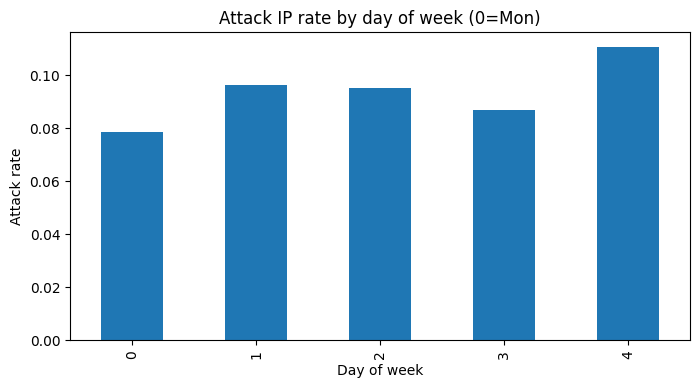

In [26]:
# We are using label=Is Attack Ip from above section

df["dayofweek"] = df["Login Timestamp"].dt.dayofweek  # 0=Mon, 6=Sun

dow_rate = df.groupby("dayofweek")[label].mean()
print(dow_rate)

dow_rate.plot(kind="bar", figsize=(8,4))
plt.title("Attack IP rate by day of week (0=Mon)")
plt.xlabel("Day of week")
plt.ylabel("Attack rate")
plt.show()

Mention this later in report

> “Attack IPs appear slightly more frequent on some weekdays (e.g., day 4), but the variation is modest compared to the stronger off-hours pattern seen between 1–6 AM.”



```
# This is why we choose 'hour of day' rather than 'day of week'
```





# 4. User Profiling

Per-User Statistics



```
# 	•	Most users:
	•	events: 1–3 logins
	•	unique_ips: 1
	•	unique_devices: 1
	•	A few users:
	•	huge numbers of events and IPs (crazy outliers)
```

Conclusion: Our model will classify login events
e.g. “This login at 02:13 from IP X with device Y – risky or not?”

We’re not classifying users as “good/bad”. The user-level stats are just to understand behavior, not the final thing we feed directly to the model.


In [27]:
user_stats = df.groupby("User ID").agg(
    events=("Login Timestamp", "count"),
    success_rate=("Login Successful", "mean"),
    unique_ips=("IP Address", "nunique"),
    unique_cities=("City", "nunique"),
    unique_devices=("Device Type", "nunique"),
    attack_rate=("Is Attack IP", "mean"),
    median_rtt=("Round-Trip Time [ms]", "median"),
)

summary = user_stats.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T
print(summary)

                   count        mean         std   min    50%    75%    90%  \
events          114804.0    2.613149  312.820465   1.0    1.0    2.0    3.0   
success_rate    114804.0    0.771322    0.384358   0.0    1.0    1.0    1.0   
unique_ips      114804.0    1.535548  142.025424   1.0    1.0    1.0    1.0   
unique_cities   114804.0    1.106277   12.251682   1.0    1.0    1.0    1.0   
unique_devices  114804.0    1.049885    0.224329   1.0    1.0    1.0    1.0   
attack_rate     114804.0    0.070753    0.251237   0.0    0.0    0.0    0.0   
median_rtt      114804.0  545.919615  143.589861  11.0  541.0  541.0  541.0   

                  95%       max  
events            4.0  105992.0  
success_rate      1.0       1.0  
unique_ips        2.0   48123.0  
unique_cities     2.0    4151.0  
unique_devices    1.0       5.0  
attack_rate       1.0       1.0  
median_rtt      541.0   23290.0  


Checking Visuals of Unique IP Unique Device

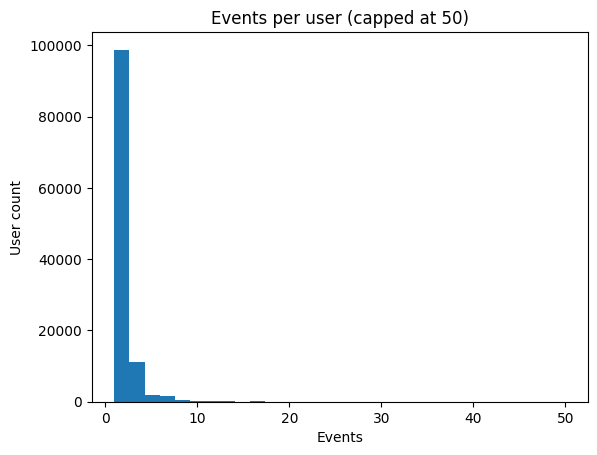

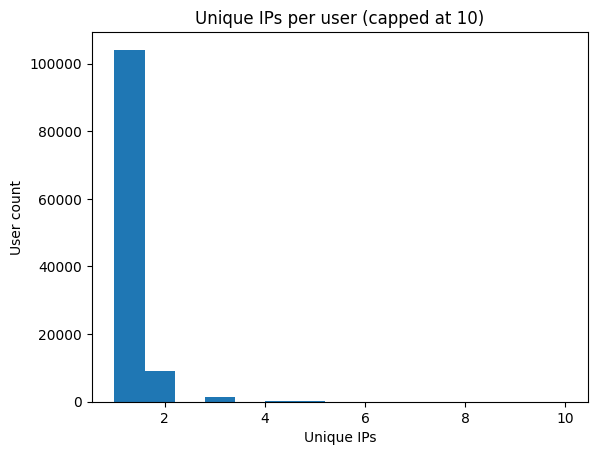

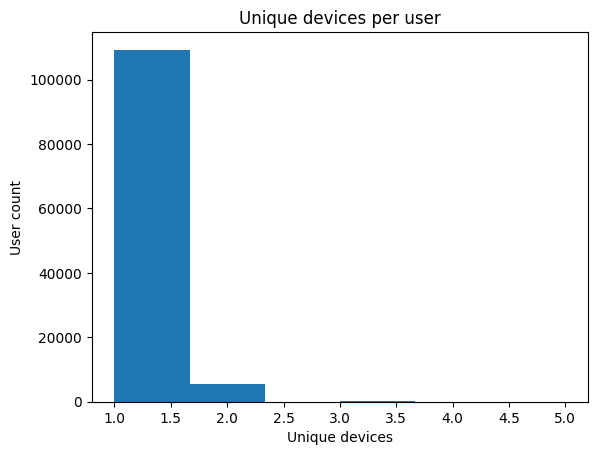

In [28]:
# Cap very large values just for plotting so histograms are readable
events_capped = user_stats["events"].clip(upper=50)
ips_capped = user_stats["unique_ips"].clip(upper=10)
devices = user_stats["unique_devices"]

plt.hist(events_capped, bins=30)
plt.title("Events per user (capped at 50)")
plt.xlabel("Events")
plt.ylabel("User count")
plt.show()

plt.hist(ips_capped, bins=15)
plt.title("Unique IPs per user (capped at 10)")
plt.xlabel("Unique IPs")
plt.ylabel("User count")
plt.show()

plt.hist(devices, bins=6)
plt.title("Unique devices per user")
plt.xlabel("Unique devices")
plt.ylabel("User count")
plt.show()

Risk for new vs seen Device & IP

Conclusion:

```
# So in this dataset:
	•	Logins from devices/IPs that have been seen before for that user (flag = 0)
→ actually have higher attack IP rate
	•	First-time device/IP for that user (flag = 1)
→ lower attack IP rate

This is the opposite of the naive “new device = bad” story and tells us something about how this dataset behaves.


```



In [29]:
# Make sure data is sorted by user + time
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

# 1) New device for this user?
df["is_new_device_for_user"] = (
    df.groupby("User ID")["Device Type"]
      .apply(lambda s: (~s.duplicated()).astype(int))  # 1 = first time this device seen for this user
      .reset_index(level=0, drop=True)
)

# 2) New IP for this user?
df["is_new_ip_for_user"] = (
    df.groupby("User ID")["IP Address"]
      .apply(lambda s: (~s.duplicated()).astype(int))  # 1 = first time this IP seen for this user
      .reset_index(level=0, drop=True)
)

Attack rate: new vs seen device

Attack rate by new/seen device:
is_new_device_for_user
0    0.108314
1    0.068140
Name: Is Attack IP, dtype: float64

Counts by new/seen device:
is_new_device_for_user
0    179469
1    120531
Name: count, dtype: int64


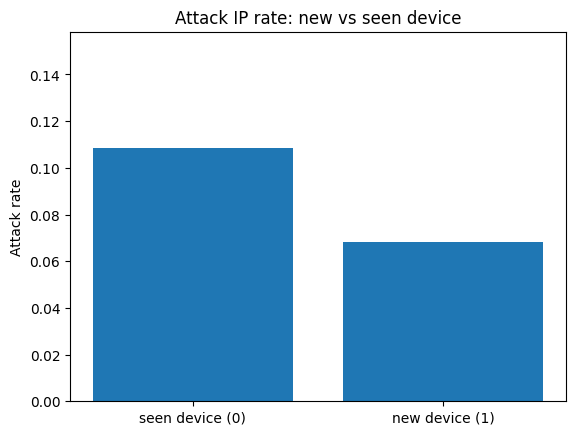

In [30]:
import matplotlib.pyplot as plt

# Make a small summary table for device
device_risk = df.groupby("is_new_device_for_user")["Is Attack IP"].mean()
device_counts = df["is_new_device_for_user"].value_counts()

print("Attack rate by new/seen device:")
print(device_risk)
print("\nCounts by new/seen device:")
print(device_counts)

# Map 0/1 to labels for the x-axis
device_labels = ["seen device (0)", "new device (1)"]
device_rates = [device_risk[0], device_risk[1]]

plt.bar(device_labels, device_rates)
plt.title("Attack IP rate: new vs seen device")
plt.ylabel("Attack rate")
plt.ylim(0, max(device_rates) + 0.05)
plt.show()

Attack rate: new vs seen IP

Attack rate by new/seen IP:
is_new_ip_for_user
0    0.121798
1    0.071384
Name: Is Attack IP, dtype: float64

Counts by new/seen IP:
is_new_ip_for_user
1    176287
0    123713
Name: count, dtype: int64


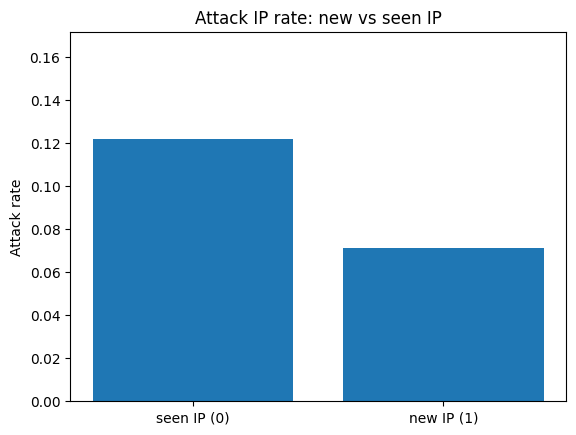

In [31]:
# Summary for IP
ip_risk = df.groupby("is_new_ip_for_user")["Is Attack IP"].mean()
ip_counts = df["is_new_ip_for_user"].value_counts()

print("Attack rate by new/seen IP:")
print(ip_risk)
print("\nCounts by new/seen IP:")
print(ip_counts)

ip_labels = ["seen IP (0)", "new IP (1)"]
ip_rates = [ip_risk[0], ip_risk[1]]

plt.bar(ip_labels, ip_rates)
plt.title("Attack IP rate: new vs seen IP")
plt.ylabel("Attack rate")
plt.ylim(0, max(ip_rates) + 0.05)
plt.show()

Risk Concentration by Category

In [32]:
def lift_table(data, col, label_col, min_count=100, top=10):
    tmp = (
        data.groupby(col)[label_col]
        .agg(count="count", pos_rate="mean")
        .query("count >= @min_count")     # keep only values with enough rows
        .sort_values("pos_rate", ascending=False)
    )
    return tmp.head(top)

device_lift = lift_table(df, "Device Type", label)
country_lift = lift_table(df, "Country", label)
region_lift = lift_table(df, "Region", label)
city_lift = lift_table(df, "City", label)

print("Top risky Device Types:")
print(device_lift)

print("\nTop risky Countries:")
print(country_lift)

print("\nTop risky Countries:")
print(region_lift)

print("\nTop risky Countries:")
print(city_lift)

Top risky Device Types:
              count  pos_rate
Device Type                  
bot             234  0.773504
unknown         167  0.323353
mobile       212206  0.117080
desktop       78276  0.029779
tablet         9117  0.026434

Top risky Countries:
         count  pos_rate
Country                 
ru         313  0.549521
cl         442  0.533937
ro        1733  0.466821
iq         113  0.362832
us       64532  0.310187
vn         225  0.288889
pk         203  0.266010
ph         474  0.175105
tr        1660  0.137952
id        4292  0.129077

Top risky Countries:
            count  pos_rate
Region                     
new jersey    133  0.864662
illinois      139  0.712230
virginia      118  0.703390
moscow        135  0.674074
bucuresti     797  0.608532
washington    164  0.603659
california    200  0.585000
new york      231  0.393939
silesia      1572  0.341603
colorado      157  0.331210

Top risky Countries:
               count  pos_rate
City                          
cz

Conclusion:

Device
```
	•	bot: ~77% of events from “bot” device type are attack IPs
→ basically “if device_type = bot, it’s almost always malicious”.
	•	unknown: ~32% attack rate
→ still very high risk compared to normal users.
	•	mobile: ~11.7% attack rate
→ slightly above the overall dataset average (~9.7%), so mildly riskier.
	•	desktop / tablet: ~2.6–3% attack rate
→ clearly lower risk segment.
```
From EDA, we observed that logins labeled as ‘bot’ or ‘unknown’ device types have much higher attack IP rates, whereas desktop and tablet devices show much lower risk. This supports including device type as both a rule signal and a model feature.

Country


```
# In the provided RBA dataset, certain source countries show significantly higher attack IP rates. This likely reflects how the dataset was constructed (e.g., simulated attack traffic originating from specific regions) rather than real-world population risk. We therefore treat country as a contextual risk feature, but interpret it cautiously.”
```




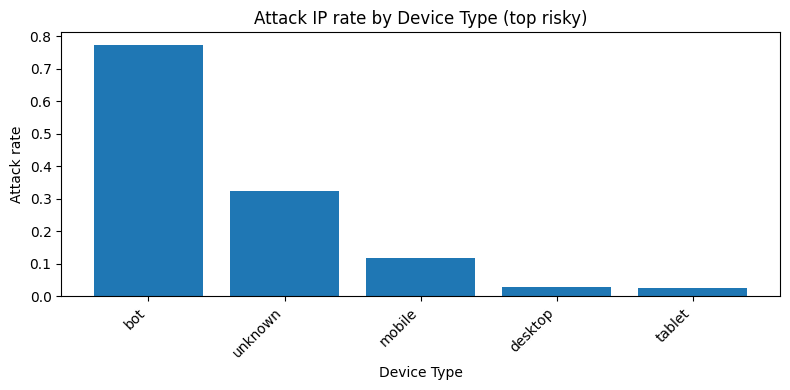

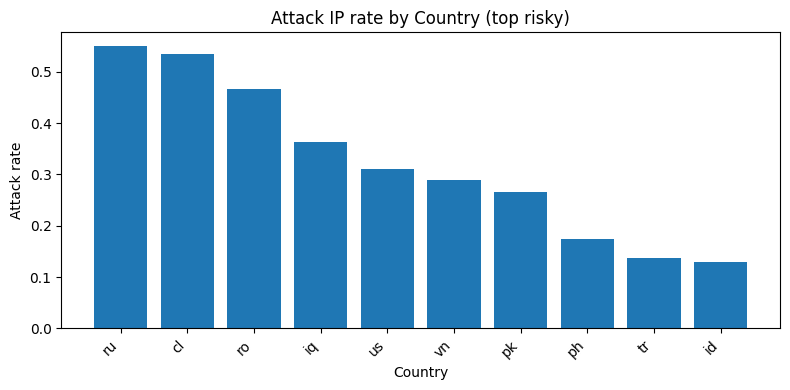

In [33]:
import matplotlib.pyplot as plt

# Device Type plot
if not device_lift.empty:
    plt.figure(figsize=(8,4))
    plt.bar(device_lift.index.astype(str), device_lift["pos_rate"])
    plt.title("Attack IP rate by Device Type (top risky)")
    plt.xlabel("Device Type")
    plt.ylabel("Attack rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Country plot
if not country_lift.empty:
    plt.figure(figsize=(8,4))
    plt.bar(country_lift.index.astype(str), country_lift["pos_rate"])
    plt.title("Attack IP rate by Country (top risky)")
    plt.xlabel("Country")
    plt.ylabel("Attack rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## EDA Summary – RBA Dataset (300k Sample)

### 1. Label Distribution
- Using `Is Attack IP` as the main label for analysis.
- In the 300k sample, ~**9–10%** of events are labeled as attack IPs.
- `Is Account Takeover` is extremely rare in the smaller sample (all zeros), so not used for early EDA.

---

### 2. Time-Based Patterns
- **Hour of day:** Clear off-hours spike in attack rate between **1 AM–6 AM**, with peaks around **2–5 AM**.
- **Day of week (0–4 / Mon–Fri):** Attack rate varies slightly (~8–11%), but differences are small.
- → **Time-of-day is a stronger risk signal than day-of-week** in this dataset.

---

### 3. User Behavior Profile
- **Users:** 114k+ unique users in the 300k slice.
- **Activity per user:**
  - Median events per user ≈ **1**
  - 90th percentile ≈ **3**, 95th ≈ **4**
- **Stability:**
  - Most users use **1 IP** and **1 device**.
  - A few extreme outliers have **very high event and IP counts**, likely synthetic or attacker-style accounts.
- Most users have high login success rates and never touch attack IPs; a small subset shows concentrated attack activity.

---

### 4. New vs Seen Device/IP
- Flags:
  - `is_new_device_for_user` = 1 on first time user uses a given device type.
  - `is_new_ip_for_user` = 1 on first time user uses a given IP.
- In this dataset:
  - **Seen devices/IPs (flag = 0)** have *higher* attack IP rates than first-time devices/IPs.
- Interpretation:
  - Suggests **attacker persistence** (reuse of the same IP/device) rather than only one-off random new IPs.
  - “New = suspicious” is **not always true** here; newness should be one signal among several.

---

### 5. Device Type Risk Patterns
- Attack IP rate by `Device Type` (with min count threshold):
  - `bot` ≈ **77%**
  - `unknown` ≈ **32%**
  - `mobile` ≈ **11.7%**
  - `desktop` / `tablet` ≈ **2–3%**
- → `bot` and `unknown` behave like high-risk device categories; desktop/tablet appear relatively safer.

---

### 6. Country-Level Patterns (Contextual Only)
- Some source countries in the dataset show **elevated attack IP rates** (e.g., `ru`, `cl`, `ro`, `iq`, `us`).
- This likely reflects **dataset construction / simulated attack traffic**, not real-world population behavior.
- Country is treated as a **contextual network feature**, not a user-level judgment.

---

### 7. Takeaways for Next Steps
- Clear, interpretable patterns:
  - Off-hours logins, certain device types, and some origin countries correlate strongly with attack IPs.
  - Most users are stable (single IP, single device), while attackers show outlier or persistent patterns.
- These insights will guide:
  - Design of a **rule-based baseline** (time, device type, simple context).
  - Later **feature engineering** for intent-based ML (behavior + context + history).

Failed logins are more strongly associated with attack IPs than successful logins, but a non-trivial number of successful logins also come from attack IPs. This supports using failure patterns as an important risk feature, while not assuming that all attacks necessarily fail.

In [34]:

print("Login Successful value counts:")
print(df["Login Successful"].value_counts())

print("\nAttack IP rate by login outcome:")
print(df.groupby("Login Successful")[label].mean())

print("\nCrosstab of Login Successful vs Attack IP:")
print(pd.crosstab(df["Login Successful"], df[label]))


Login Successful value counts:
Login Successful
False    153257
True     146743
Name: count, dtype: int64

Attack IP rate by login outcome:
Login Successful
False    0.122278
True     0.060732
Name: Is Attack IP, dtype: float64

Crosstab of Login Successful vs Attack IP:
Is Attack IP       False  True 
Login Successful               
False             134517  18740
True              137831   8912


Logins Per Minute + Attack Rate Over Time




```
Login volume shows a strong daily pattern with higher activity in daytime hours and lower activity at night, with additional short-term spikes in traffic.
```


```
Attack IP rate over time appears in bursts rather than being evenly distributed, indicating periods of concentrated attack activity, possibly reflecting scripted or campaign-style behavior
```



/tmp/ipython-input-704909066.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  logins_per_min = df.groupby(df["Login Timestamp"].dt.floor("T")).size()


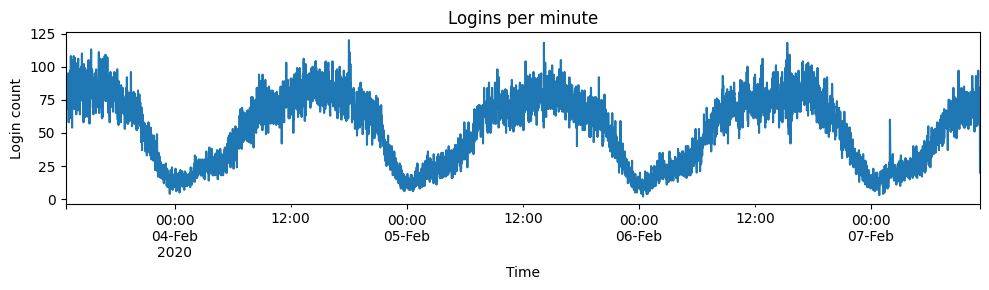

/tmp/ipython-input-704909066.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  attack_rate_per_min = df.groupby(df["Login Timestamp"].dt.floor("T"))[label].mean()


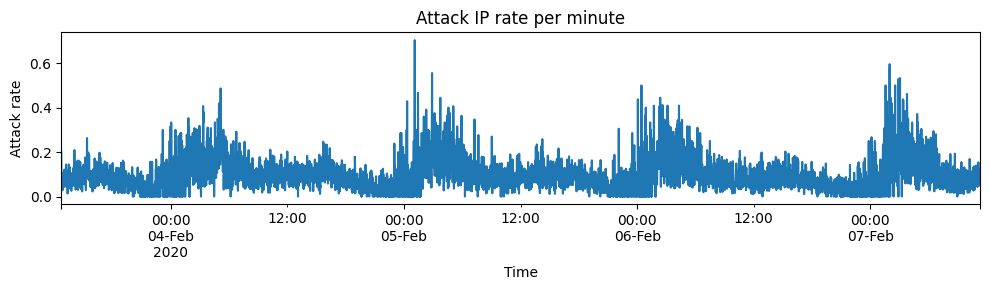

In [35]:
label = "Is Attack IP"

# Logins per minute
logins_per_min = df.groupby(df["Login Timestamp"].dt.floor("T")).size()

plt.figure(figsize=(10,3))
logins_per_min.plot()
plt.title("Logins per minute")
plt.xlabel("Time")
plt.ylabel("Login count")
plt.tight_layout()
plt.show()

# Attack rate per minute
attack_rate_per_min = df.groupby(df["Login Timestamp"].dt.floor("T"))[label].mean()

plt.figure(figsize=(10,3))
attack_rate_per_min.plot()
plt.title("Attack IP rate per minute")
plt.xlabel("Time")
plt.ylabel("Attack rate")
plt.tight_layout()
plt.show()

# **For now keep it as it is!. Will remove at the end**

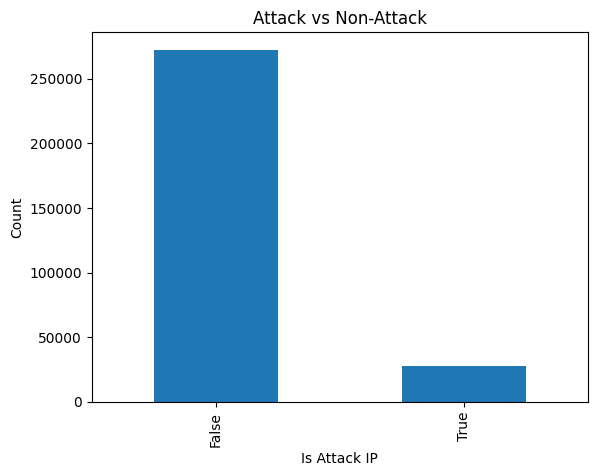

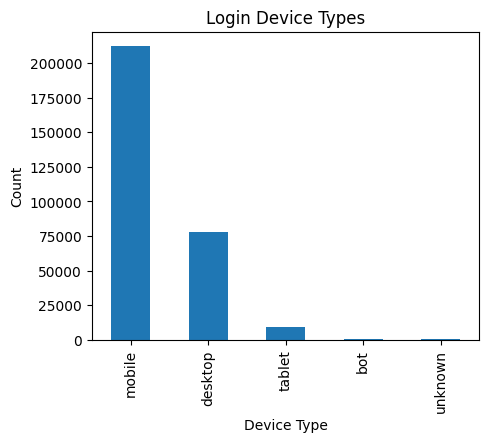

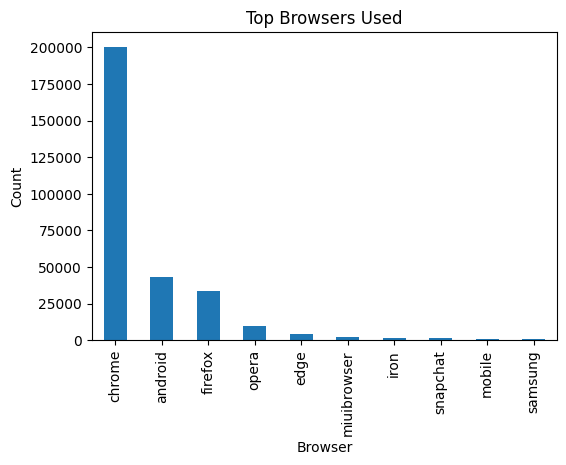

In [36]:
df["Is Attack IP"].value_counts().plot(kind="bar")
plt.title("Attack vs Non-Attack")
plt.xlabel("Is Attack IP")
plt.ylabel("Count")
plt.show()

df["Device Type"].value_counts().plot(kind="bar", figsize=(5,4))
plt.title("Login Device Types")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

df["browser"].value_counts().head(10).plot(kind="bar", figsize=(6,4))
plt.title("Top Browsers Used")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.show()

In [37]:
print("Shape:", df.shape)

Shape: (300000, 22)


In [38]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,...,Device Type,Login Successful,Is Attack IP,Is Account Takeover,browser,os,hour,dayofweek,is_new_device_for_user,is_new_ip_for_user
0,250910,2020-02-06 17:10:54.364,-9223287066183308537,541.0,84.209.76.159,no,oslo county,oslo,41164,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,...,desktop,True,False,False,chrome,mac,17,3,1,1
1,263173,2020-02-06 19:52:41.530,-9223258649185196422,541.0,91.208.148.129,no,-,-,49310,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,...,mobile,False,False,False,android,ios,19,3,1,1
2,267032,2020-02-06 20:55:19.627,-9223258649185196422,541.0,91.208.148.129,no,-,-,49310,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,...,mobile,True,False,False,android,ios,20,3,0,0
3,191736,2020-02-05 21:03:20.657,-9223200578825105501,541.0,79.161.56.83,no,vestfold og telemark,holmestrand,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,...,mobile,True,False,False,chrome,ios,21,2,1,1
4,260449,2020-02-06 19:12:29.501,-9223199305075633823,541.0,79.161.86.86,no,-,-,29695,Mozilla/5.0 (Linux; U; Android 13.0; i phone X...,...,mobile,True,False,False,opera,android,19,3,1,1


# So far we created Features -

1.   browser, os
2.   hour, dayofweek      → time features
3. is_new_device_for_user → behavioral history flag
4. is_new_ip_for_user     → behavioral history flag

Removed Index col for noice

In [39]:
df = df.drop(columns=["index", "level_0"], errors="ignore")

Validating Cols So far

In [40]:
# 2. Make sure timestamp is datetime and time features exist
df["Login Timestamp"] = pd.to_datetime(df["Login Timestamp"], errors="coerce")

df["hour"] = df["Login Timestamp"].dt.hour
df["dayofweek"] = df["Login Timestamp"].dt.dayofweek

print(df[["Login Timestamp", "hour", "dayofweek"]].head())
print("\nColumns now in df:")
print(df.columns.tolist())

          Login Timestamp  hour  dayofweek
0 2020-02-06 17:10:54.364    17          3
1 2020-02-06 19:52:41.530    19          3
2 2020-02-06 20:55:19.627    20          3
3 2020-02-05 21:03:20.657    21          2
4 2020-02-06 19:12:29.501    19          3

Columns now in df:
['Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover', 'browser', 'os', 'hour', 'dayofweek', 'is_new_device_for_user', 'is_new_ip_for_user']


Now will create a feature to determine if attack was in off_hours of what we determine first (i.e. 1-6 AM)

In ML, it becomes a very interpretable feature:
	•	Model can learn that “off-hours + other weird things” → higher risk.

In [41]:
# Off-hours = 1 if login between 1 AM and 6 AM inclusive
df["is_off_hours"] = df["hour"].between(1, 6).astype(int)

print(df["is_off_hours"].value_counts())

is_off_hours
0    260702
1     39298
Name: count, dtype: int64


Let’s quickly sanity-check that is_off_hours actually correlates with higher attack rate (like we saw in EDA), then we’ll move on to history-based features.

In [42]:
# Validating. Check how strong is_off_hours is

	# •	is_off_hours = 0 → lower attack rate
	# •	is_off_hours = 1 → higher attack rate

# Normal hours (is_off_hours = 0): ~8.17% attack IP
# 	•	Off-hours (is_off_hours = 1): ~16.14% attack IP

label = "Is Attack IP"

print("Attack IP rate by is_off_hours:")
print(df.groupby("is_off_hours")[label].mean())

Attack IP rate by is_off_hours:
is_off_hours
0    0.081741
1    0.161382
Name: Is Attack IP, dtype: float64


failed_login (basic outcome signal)

In [43]:
df["failed_login"] = (~df["Login Successful"]).astype(int)

print(df[["Login Successful", "failed_login"]].head())
print("\nfailed_login value counts:")
print(df["failed_login"].value_counts())

   Login Successful  failed_login
0              True             0
1             False             1
2              True             0
3              True             0
4              True             0

failed_login value counts:
failed_login
1    153257
0    146743
Name: count, dtype: int64


failures_last_5 (recent failure burst)

In [44]:
# Make sure data is ordered by user + time
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

# For each user, count failed logins in the previous 5 events
df["failures_last_5"] = (
    df.groupby("User ID")["failed_login"]
      .apply(lambda s: s.shift().rolling(window=5, min_periods=1).sum())
      .reset_index(level=0, drop=True)
)

print(df[["User ID", "Login Timestamp", "failed_login", "failures_last_5"]].head(10))

print("\nfailures_last_5 summary:")
print(df["failures_last_5"].describe())

print("\nAttack rate by failures_last_5 (0–5):")
print(df.groupby("failures_last_5")["Is Attack IP"].mean())

               User ID         Login Timestamp  failed_login  failures_last_5
0 -9223287066183308537 2020-02-06 17:10:54.364             0              NaN
1 -9223258649185196422 2020-02-06 19:52:41.530             1              NaN
2 -9223258649185196422 2020-02-06 20:55:19.627             0              1.0
3 -9223200578825105501 2020-02-05 21:03:20.657             0              NaN
4 -9223199305075633823 2020-02-06 19:12:29.501             0              NaN
5 -9223121694105191762 2020-02-06 09:30:49.497             0              NaN
6 -9223105192037990674 2020-02-05 16:02:27.917             0              NaN
7 -9222787717423219151 2020-02-05 15:13:18.865             0              NaN
8 -9222787717423219151 2020-02-05 15:17:50.854             1              0.0
9 -9222772478737808777 2020-02-03 16:41:05.823             0              NaN

failures_last_5 summary:
count    185196.000000
mean          3.150424
std           2.233000
min           0.000000
25%           1.000000
5

In [45]:
# Replace NaN (no history) with 0, and make it integer
df["failures_last_5"] = df["failures_last_5"].fillna(0).clip(0, 5).astype(int)

print(df["failures_last_5"].value_counts().sort_index())

failures_last_5
0    158465
1     24801
2      6513
3      2267
4       952
5    107002
Name: count, dtype: int64


Next tiny step: failure_streak (consecutive failures)

How many consecutive failed logins has this user had just before this event?

In [46]:
import numpy as np

def compute_failure_streak(s):
    """
    For each user's failed_login series, compute how many
    consecutive failures occurred immediately BEFORE this event.
    """
    prev = s.shift()  # look at previous outcomes only
    streak = []
    current = 0
    for v in prev:
        if pd.isna(v) or v == 0:
            current = 0
        else:  # v == 1 (previous event was a failure)
            current += 1
        streak.append(current)
    return pd.Series(streak, index=s.index)

# Apply per user
df["failure_streak"] = (
    df.groupby("User ID")["failed_login"]
      .apply(compute_failure_streak)
      .reset_index(level=0, drop=True)
)

print(df[["User ID", "Login Timestamp", "failed_login", "failure_streak"]].head(12))

print("\nfailure_streak summary:")
print(df["failure_streak"].describe())

print("\nAttack rate by failure_streak (0–5):")
print(
    df.assign(failure_streak_capped=df["failure_streak"].clip(0, 5))
      .groupby("failure_streak_capped")["Is Attack IP"].mean()
)

                User ID         Login Timestamp  failed_login  failure_streak
0  -9223287066183308537 2020-02-06 17:10:54.364             0               0
1  -9223258649185196422 2020-02-06 19:52:41.530             1               0
2  -9223258649185196422 2020-02-06 20:55:19.627             0               1
3  -9223200578825105501 2020-02-05 21:03:20.657             0               0
4  -9223199305075633823 2020-02-06 19:12:29.501             0               0
5  -9223121694105191762 2020-02-06 09:30:49.497             0               0
6  -9223105192037990674 2020-02-05 16:02:27.917             0               0
7  -9222787717423219151 2020-02-05 15:13:18.865             0               0
8  -9222787717423219151 2020-02-05 15:17:50.854             1               0
9  -9222772478737808777 2020-02-03 16:41:05.823             0               0
10 -9222035471022096918 2020-02-06 20:05:52.296             0               0
11 -9222021806417972337 2020-02-04 16:56:50.279             1   

In [47]:
# Cap failure_streak at 5 for modeling/rules (5 = 5+ consecutive failures)
df["failure_streak_capped"] = df["failure_streak"].clip(0, 5).astype(int)

print(df["failure_streak_capped"].value_counts().sort_index())

failure_streak_capped
0    170309
1     17259
2      3695
3      1203
4       532
5    107002
Name: count, dtype: int64


#Derived Features


In [48]:
# location key
df["location"] = df["Country"] + "," + df["Region"] + "," + df["City"]

# valid only if Region & City are real
valid = (~df["Region"].isin(["-", "Unknown"])) & (~df["City"].isin(["-", "Unknown"]))
prev_valid = valid.groupby(df["User ID"]).shift()

# raw change per user
raw_change = df["location"].ne(df.groupby("User ID")["location"].shift())

# final flag: change + valid now + valid before, and not first login
df["new_location_flag"] = (raw_change & valid & prev_valid).fillna(False).astype(int)

rows = df[df["new_location_flag"] == 1].index[:10]

df.loc[rows, ["User ID", "Login Timestamp", "location"]].assign(
    prev_location=df.groupby("User ID")["location"].shift().loc[rows]
)




,User ID,Login Timestamp,location,prev_location
108,-9212691437216456604,2020-02-06 10:02:29.650,"no,oslo county,oslo","no,viken,ski"
127,-9210978471105055787,2020-02-05 15:23:58.239,"no,rogaland,stavanger","no,møre og romsdal,kleppe"
157,-9207764783741112639,2020-02-06 10:59:13.721,"no,troms og finnmark,harstad","no,rogaland,sandnes"
169,-9205900727938134073,2020-02-06 19:04:43.223,"no,vestland,skulestadmo","no,oslo county,oslo"
170,-9205900727938134073,2020-02-06 20:06:38.543,"no,rogaland,bryne","no,vestland,skulestadmo"
171,-9205900727938134073,2020-02-06 20:32:36.520,"no,agder,fevik","no,rogaland,bryne"
261,-9195028939186396673,2020-02-05 16:28:50.992,"no,nordland,mo i rana","no,vestfold og telemark,horten"
277,-9194035224016458551,2020-02-05 08:05:18.882,"no,vestland,torvikbygd","no,viken,kongsberg"
278,-9194035224016458551,2020-02-07 06:43:51.636,"no,viken,kongsberg","no,vestland,torvikbygd"
332,-9189683953892644950,2020-02-04 18:11:51.939,"no,oslo county,oslo","no,vestland,svortland"


In [49]:
# New ASN flag (derived)

# Normalize ASN values
df["ASN"] = df["ASN"].replace(["-", "Unknown", ""], pd.NA)

# Valid ASN rows
valid_asn = df["ASN"].notna()

# Previous login had valid ASN
prev_valid_asn = valid_asn.groupby(df["User ID"]).shift()

# ASN changed from previous login
asn_change = df["ASN"].ne(df.groupby("User ID")["ASN"].shift())

# Final flag: real ASN change only
df["new_asn_flag"] = (
    asn_change & valid_asn & prev_valid_asn
).fillna(False).astype(int)

rows = df[df["new_asn_flag"] == 1].index[:10]

df.loc[rows, ["User ID", "Login Timestamp", "ASN"]].assign(
    prev_ASN=df.groupby("User ID")["ASN"].shift().loc[rows]
)

,User ID,Login Timestamp,ASN,prev_ASN
41,-9218566219650443411,2020-02-06 12:33:10.231,224,29695
51,-9218199126639810598,2020-02-06 14:09:22.926,55784,29695
108,-9212691437216456604,2020-02-06 10:02:29.650,41164,29695
116,-9212015686641660881,2020-02-05 22:31:49.968,29695,208966
171,-9205900727938134073,2020-02-06 20:32:36.520,207674,25400
172,-9205900727938134073,2020-02-06 21:39:34.369,25400,207674
173,-9205900727938134073,2020-02-06 22:53:47.380,29695,25400
212,-9199928068777816171,2020-02-05 15:55:16.976,29695,207464
277,-9194035224016458551,2020-02-05 08:05:18.882,500018,29695
278,-9194035224016458551,2020-02-07 06:43:51.636,29695,500018


new_device_flag = 1 → real device change
new_device_flag = 0 → same device OR first login OR missing device info

In [50]:
# -------------------------------
# New Device flag (derived)
# 1 → real device change
# 0 → same device / first login / missing-data transition
# -------------------------------

# Step 1: Build a device fingerprint
# Combines device type, OS, browser, and user agent
df["device_fingerprint"] = (
    df["Device Type"].fillna("") + "," +
    df["OS Name and Version"].fillna("") + "," +
    df["Browser Name and Version"].fillna("") + "," +
    df["User Agent String"].fillna("")
)

# Step 2: Identify valid device rows
# A device is valid only if key fields are present
df["valid_device"] = (
    df["Device Type"].notna() &
    df["OS Name and Version"].notna() &
    df["Browser Name and Version"].notna()
)

# Step 3: Detect raw device change per user
device_change = df["device_fingerprint"].ne(
    df.groupby("User ID")["device_fingerprint"].shift()
)

# Step 4: Check if previous login also had a valid device
prev_valid_device = df["valid_device"].groupby(df["User ID"]).shift()

# Step 5: Final New Device flag
df["new_device_flag"] = (
    device_change &
    df["valid_device"] &
    prev_valid_device
).fillna(False).astype(int)

rows = df[df["new_device_flag"] == 1].index[:10]

df.loc[rows, ["User ID", "Login Timestamp", "device_fingerprint"]].assign(
    prev_device=df.groupby("User ID")["device_fingerprint"].shift().loc[rows]
)


,User ID,Login Timestamp,device_fingerprint,prev_device
15,-9221337715387154957,2020-02-04 12:05:48.297,"mobile,iOS 13.4,Firefox 20.0.0.1673,Mozilla/5....","mobile,iOS 7.1,Opera Mini 19.0.2254,Opera/9.80..."
25,-9220078102273280830,2020-02-04 14:43:37.160,"desktop,Mac OS X 10.14.6,Chrome 69.0.3497.17.1...","desktop,Mac OS X 10.14.6,Chrome 90.0.4411,Mozi..."
38,-9218566219650443411,2020-02-05 18:37:32.178,"tablet,iOS 7.1,Android 2.3.3.2672,Mozilla/5.0 ...","desktop,Chrome OS 13505.73.0,Chrome 72.0.3626...."
40,-9218566219650443411,2020-02-05 18:46:12.332,"mobile,iOS 11.2.6,Chrome Mobile WebView 85.0.4...","tablet,iOS 7.1,Android 2.3.3.2672,Mozilla/5.0 ..."
41,-9218566219650443411,2020-02-06 12:33:10.231,"desktop,Mac OS X 10.14.6,Chrome 73.0.3654,Mozi...","mobile,iOS 11.2.6,Chrome Mobile WebView 85.0.4..."
51,-9218199126639810598,2020-02-06 14:09:22.926,"desktop,Chrome OS 5978.98.0,Chrome 72.0.3626.6...","mobile,iOS 14.2.1,Firefox 20.0.0.1618,Mozilla/..."
81,-9215100599027469904,2020-02-05 08:06:01.017,"mobile,iOS 11.2.6,Chrome Mobile WebView 85.0.4...","desktop,Mac OS X 10.14.6,Chrome 69.0.3497.17.1..."
82,-9215100599027469904,2020-02-05 08:13:08.902,"desktop,Mac OS X 10.14.6,Chrome 69.0.3497.17.1...","mobile,iOS 11.2.6,Chrome Mobile WebView 85.0.4..."
85,-9214905419842092186,2020-02-06 11:59:20.129,"desktop,Mac OS X 10.14.6,Chrome 90.0.4411,Mozi...","desktop,Mac OS X 10.14.6,Chrome 90.0.4411,Mozi..."
95,-9213479746116406881,2020-02-05 20:16:44.077,"mobile,iOS 7.1,Android 2.3.3.2672,Mozilla/5.0 ...","desktop,Mac OS X 10.14.6,Chrome 69.0.3497.17.1..."


### Quickly check attack rate for new_location_flag, new_asn_flag, new_device_flag (like we did for off-hours)
📌 Conclusion:
new_location_flag is still worth keeping, but:
	•	It’s not a “red flag” feature.
	•	It might even be slightly protective (or just noisy).
	•	We won’t use it as a strong positive risk factor in the rule baseline. At most, it’ll be a weak/contextual signal, or we leave it for ML to interpret.
📌 Conclusion:
new_asn_flag is a useful positive risk signal, but not as strong as device type or off-hours. Good to give it a small weight in baseline and use it in ML.
📌 Conclusion:
new_device_flag is a solid contextual risk feature:
	•	Not as extreme as Device Type = bot, but clearly useful.
	•	Good for both rule-based and ML

In [51]:
for col in ["new_location_flag", "new_asn_flag", "new_device_flag"]:
    print(f"\nAttack rate by {col}:")
    print(df.groupby(col)["Is Attack IP"].mean())


Attack rate by new_location_flag:
new_location_flag
0    0.095316
1    0.065785
Name: Is Attack IP, dtype: float64

Attack rate by new_asn_flag:
new_asn_flag
0    0.082981
1    0.110928
Name: Is Attack IP, dtype: float64

Attack rate by new_device_flag:
new_device_flag
0    0.078884
1    0.113505
Name: Is Attack IP, dtype: float64


In [52]:
# --------------------------------
# Device Change Rate (derived)
# Meaning:
#   Proportion of logins where the user changed device
# --------------------------------

# Device change rate per user
df["device_change_rate"] = (
    df.groupby("User ID")["new_device_flag"]
      .transform("mean")
)

df[["User ID", "new_device_flag", "device_change_rate"]].head(10)

,User ID,new_device_flag,device_change_rate
0,-9223287066183308537,0,0.0
1,-9223258649185196422,0,0.0
2,-9223258649185196422,0,0.0
3,-9223200578825105501,0,0.0
4,-9223199305075633823,0,0.0
5,-9223121694105191762,0,0.0
6,-9223105192037990674,0,0.0
7,-9222787717423219151,0,0.0
8,-9222787717423219151,0,0.0
9,-9222772478737808777,0,0.0


In [53]:
# Sort data so "previous" and time windows are correct
df = df.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

df["ts_sec"] = df["Login Timestamp"].astype("int64") // 10**9

df["delta_sec"] = (
    df.groupby("User ID")["ts_sec"]
      .diff()
      .fillna(10**9)   # large gap for first login
)

df["new_window"] = (df["delta_sec"] > 300).astype(int)
df["window_id"] = df.groupby("User ID")["new_window"].cumsum()

df["logins_5min"] = (
    df.groupby(["User ID", "window_id"])
      .cumcount() + 1
)

df[["User ID", "Login Timestamp", "logins_5min"]].head(15)


,User ID,Login Timestamp,logins_5min
0,-9223287066183308537,2020-02-06 17:10:54.364,1
1,-9223258649185196422,2020-02-06 19:52:41.530,1
2,-9223258649185196422,2020-02-06 20:55:19.627,1
3,-9223200578825105501,2020-02-05 21:03:20.657,1
4,-9223199305075633823,2020-02-06 19:12:29.501,1
5,-9223121694105191762,2020-02-06 09:30:49.497,1
6,-9223105192037990674,2020-02-05 16:02:27.917,1
7,-9222787717423219151,2020-02-05 15:13:18.865,1
8,-9222787717423219151,2020-02-05 15:17:50.854,2
9,-9222772478737808777,2020-02-03 16:41:05.823,1


Low values (1–2) → normal

High values (≥5) → malicious automation
| Method              | Problem                        |
| ------------------- | ------------------------------ |
| rolling("5min")     | Very slow, memory-heavy        |
| burst window (this) | Fast, scalable, intent-aligned |


In [54]:
# Burst Failure Count (derived)
#For each login row:
#burst_failure_count = number of failures so far in the current 5-minute window for that user
#Example window outcomes:
#fail, fail, success, fail → 1, 2, 2, 3

# 1 = failure, 0 = success
df["failure_flag"] = (df["Login Successful"] == 0).astype(int)

# Count failures inside each 5-min window (running count)
df["burst_failure_count"] = (
    df.groupby(["User ID", "window_id"])["failure_flag"]
      .cumsum()
)
df[["User ID", "Login Timestamp", "Login Successful", "window_id", "burst_failure_count"]].head(20)

,User ID,Login Timestamp,Login Successful,window_id,burst_failure_count
0,-9223287066183308537,2020-02-06 17:10:54.364,True,1,0
1,-9223258649185196422,2020-02-06 19:52:41.530,False,1,1
2,-9223258649185196422,2020-02-06 20:55:19.627,True,2,0
3,-9223200578825105501,2020-02-05 21:03:20.657,True,1,0
4,-9223199305075633823,2020-02-06 19:12:29.501,True,1,0
5,-9223121694105191762,2020-02-06 09:30:49.497,True,1,0
6,-9223105192037990674,2020-02-05 16:02:27.917,True,1,0
7,-9222787717423219151,2020-02-05 15:13:18.865,True,1,0
8,-9222787717423219151,2020-02-05 15:17:50.854,False,1,1
9,-9222772478737808777,2020-02-03 16:41:05.823,True,1,0


In [55]:
# Failure flag: 1 = failed login, 0 = success
df["failure_flag"] = (df["Login Successful"] == 0).astype(int)

# Failure rate per user (historical)
df["failure_rate"] = (
    df.groupby("User ID")["failure_flag"]
      .transform("mean")
)
df[["User ID", "failure_rate"]].drop_duplicates().head(10)

,User ID,failure_rate
0,-9223287066183308537,0.0
1,-9223258649185196422,0.5
3,-9223200578825105501,0.0
4,-9223199305075633823,0.0
5,-9223121694105191762,0.0
6,-9223105192037990674,0.0
7,-9222787717423219151,0.5
9,-9222772478737808777,0.0
10,-9222035471022096918,0.0
11,-9222021806417972337,1.0


In [56]:
# Failure flag: 1 = failed login, 0 = success
#failure_streak_length = number of consecutive failures since the last successful login
# fail, fail, success, fail → 1, 2, 0, 1
df["failure_flag"] = (df["Login Successful"] == 0).astype(int)

# Start a new streak after every successful login
df["streak_reset"] = (df["Login Successful"] == 1).astype(int)

# Assign streak groups per user
df["streak_id"] = df.groupby("User ID")["streak_reset"].cumsum()

# Count consecutive failures within each streak
df["failure_streak_length"] = (
    df.groupby(["User ID", "streak_id"])["failure_flag"]
      .cumsum()
)

df[df["failure_streak_length"] >= 3][
    ["User ID", "Login Timestamp", "failure_streak_length"]
].head(10)


,User ID,Login Timestamp,failure_streak_length
54,-9218034984559483939,2020-02-07 10:31:50.914,3
74,-9216388791173308281,2020-02-06 14:14:35.517,3
271,-9194574199726087194,2020-02-04 22:04:54.579,3
302,-9192717495814869538,2020-02-04 15:29:52.821,3
333,-9189683953892644950,2020-02-04 18:19:12.120,3
341,-9188501183446681913,2020-02-04 21:44:01.519,3
342,-9188501183446681913,2020-02-04 21:45:14.761,4
343,-9188501183446681913,2020-02-04 21:47:32.752,5
344,-9188501183446681913,2020-02-04 21:48:57.606,6
345,-9188501183446681913,2020-02-05 20:47:28.499,7


**New Location Flag**
(Derived from: User ID, Country, Region, City)

What it captures

*  Whether a user logs in from a different physical location compared to their previous login.

Why it matters

*   Legitimate users typically exhibit location stability.
*   Attackers often introduce location discontinuity through VPNs, proxies, or botnets.

Role in the proposed framework


*   Knowledge Graph: Models transitions between geographic locations for each user.
*   LSTM: Learns temporal patterns such as:
same → same → sudden change → repeated changes.

Intent signal interpretation

Single location change → Suspicious behavior

Repeated location changes → Malicious behavior

**New ASN Flag**

(Derived from: User ID, ASN)

What it captures

*   Change in the network provider or routing path used by the user.

Why it matters

*  ASN changes are difficult to occur naturally and often indicate: VPN usage
*   Network anonymization
*   Infrastructure hopping

Role in the proposed framework

*   Knowledge Graph: Connects users, ASNs, and authentication sessions.
*   LSTM: Learns escalation patterns such as: stable ASN → sudden ASN jump → oscillation.

Intent signal interpretation
ASN jump combined with location change → High-risk behavior

Frequent ASN hopping → Automated or malicious activity

**New Device Flag**

(Derived from: Device Type, Operating System, Browser, User Agent)

What it captures

*   Whether the device fingerprint used by the user has changed.

Why it matters

*   Legitimate users generally reuse a small set of devices.
*   Attackers rotate devices or simulate multiple clients to evade detection.

Role in the proposed framework


* Knowledge Graph: Represents relationships between users and devices.
* LSTM: Detects device instability over time.

Intent signal interpretation
New device combined with new location → Suspicious behavior

New device combined with failure bursts → Malicious behavior

**Device Change Rate**

(Derived from: Historical device usage per User ID)

What it captures

* Long-term stability or instability in a user’s device usage.

Why it matters

* A single device change does not imply malicious intent.

* Frequent device changes indicate elevated risk.

Role in the proposed framework

* Serves as a contextual prior for the LSTM.

* Helps differentiate between:
Travelers (low device change rate)
Attackers (high device change rate)

Intent signal interpretation

High device change rate → Elevated baseline risk

**Logins per Time Window**

(Derived from: Timestamp, User ID)

What it captures

* Burstiness and velocity of login attempts within a short time window.

Why it matters

* Human login behavior is typically sparse and periodic.

* Automated attacks generate rapid, repeated login attempts.

Role in the proposed framework

* Acts as a temporal intensity signal.

* Strong indicator of brute-force and credential-stuffing attacks.

Intent signal interpretation

High login velocity → Malicious automation

**Burst Failure Count**

What it captures

* How many failed logins occur within a short burst window (e.g., 5 minutes) for a user.

Why it matters

* Legit users may fail once.
* Attackers often produce many failures quickly (brute force / credential stuffing).

Role in your proposed framework

* Knowledge Graph: highlights clusters of failures linked to user/device/location/ASN in a short time.

* LSTM: learns intent patterns like fail → fail → fail → success (possible takeover) or fail bursts repeatedly (automation)

Intent interpretation
High burst failures → suspicious/malicious

Burst failures + new device/location/ASN → stronger malicious evidence

**Failure Rate**

(Derived from: Login Successful, User ID)

What it captures

* The overall proportion of failed logins for a user.

Why it matters

* Legitimate users usually succeed.

* Attackers generate many failures over time.

Role in the proposed framework

* Knowledge Graph: assigns long-term risk weight to users.

* LSTM: provides historical context to interpret bursts and changes.

Intent signal
Low failure rate → legitimate
High failure rate → suspicious / malicious

Failure Streak Length

(Derived from: Login Successful, User ID)

What it captures

* The number of consecutive failed login attempts made by a user without a successful login in between.

Why it matters

* Legitimate users may fail once or twice, then succeed or stop.

* Attackers often generate long uninterrupted failure sequences.

Role in the proposed framework

* Knowledge Graph: highlights persistent failure paths per user.
* LSTM: learns escalation patterns like fail → fail → fail → fail (brute force behavior).

Intent signal

Short streaks → normal mistakes

Long streaks → malicious intent


In [57]:
df["new_device_flag"].value_counts()

,count
new_device_flag,
0,184842
1,115158


In [58]:
print("Shape:", df.shape)

Shape: (300000, 44)


In [59]:
print(df.columns.tolist())

['Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover', 'browser', 'os', 'hour', 'dayofweek', 'is_new_device_for_user', 'is_new_ip_for_user', 'is_off_hours', 'failed_login', 'failures_last_5', 'failure_streak', 'failure_streak_capped', 'location', 'new_location_flag', 'new_asn_flag', 'device_fingerprint', 'valid_device', 'new_device_flag', 'device_change_rate', 'ts_sec', 'delta_sec', 'new_window', 'window_id', 'logins_5min', 'failure_flag', 'burst_failure_count', 'failure_rate', 'streak_reset', 'streak_id', 'failure_streak_length']


Global Rarity: Location & Device Type

`How common is this location/device in the entire dataset
	•	A location that appears 100,000 times → very common → low rarity.
	•	A location that appears 5 times → rare → high rarity.

`



> •	freq = count of rows with that value
	•	rarity = 1 / freq (or a log-based version later)



In [60]:

#We alreayd have Country, Region, City --- Lets build Location_rarity
import numpy as np

# 1) Build a safe location string with explicit unknowns
df["location"] = (
    df["Country"].fillna("unknown_country") + "," +
    df["Region"].fillna("unknown_region") + "," +
    df["City"].fillna("unknown_city")
)

# 2) Global frequency per location
loc_counts = df["location"].value_counts(dropna=True)

# 3) Map to each row
df["location_freq"] = df["location"].map(loc_counts)

# 4) Simple rarity 1/freq
df["location_rarity"] = 1.0 / df["location_freq"]

print(df[["location", "location_freq", "location_rarity"]].head())
print("\nlocation_freq summary:")
print(df["location_freq"].describe())
print("\nlocation_rarity summary:")
print(df["location_rarity"].describe())

print("	•	Very common locations (like no,-,- with 34,218 rows) → low rarity (~0.000029) •	Very rare locations (freq = 1) → high rarity (= 1.0)")

                              location  location_freq  location_rarity
0                  no,oslo county,oslo          25197         0.000040
1                               no,-,-          34218         0.000029
2                               no,-,-          34218         0.000029
3  no,vestfold og telemark,holmestrand            198         0.005051
4                               no,-,-          34218         0.000029

location_freq summary:
count    300000.000000
mean      16546.511680
std       20688.662714
min           1.000000
25%         316.000000
50%        2845.000000
75%       34218.000000
max       53507.000000
Name: location_freq, dtype: float64

location_rarity summary:
count    300000.000000
mean          0.019470
std           0.092547
min           0.000019
25%           0.000029
50%           0.000351
75%           0.003165
max           1.000000
Name: location_rarity, dtype: float64
	•	Very common locations (like no,-,- with 34,218 rows) → low rarity (~0.000029) •

device_type_rarity


In [61]:
# Global counts per device type
df["Device Type"] = df["Device Type"].fillna("unknown_device")

dev_counts = df["Device Type"].value_counts(dropna=True)
# Frequency & rarity per row
df["device_type_freq"] = df["Device Type"].map(dev_counts)
df["device_type_rarity"] = 1.0 / df["device_type_freq"]

print(df[["Device Type", "device_type_freq", "device_type_rarity"]].head())

print("\ndevice_type_freq summary:")
print(df["device_type_freq"].describe())

print("\ndevice_type_rarity summary:")
print(df["device_type_rarity"].describe())

  Device Type  device_type_freq  device_type_rarity
0     desktop             78276            0.000013
1      mobile            212206            0.000005
2      mobile            212206            0.000005
3      mobile            212206            0.000005
4      mobile            212206            0.000005

device_type_freq summary:
count    300000.000000
mean     170805.736487
std       65419.670911
min         167.000000
25%       78276.000000
50%      212206.000000
75%      212206.000000
max      212206.000000
Name: device_type_freq, dtype: float64

device_type_rarity summary:
count    300000.000000
mean          0.000017
std           0.000185
min           0.000005
25%           0.000005
50%           0.000005
75%           0.000013
max           0.005988
Name: device_type_rarity, dtype: float64


asn_rarity (Optional)

In [62]:
asn_counts = df["ASN"].value_counts()

df["asn_freq"] = df["ASN"].map(asn_counts)
df["asn_rarity"] = 1.0 / df["asn_freq"]

print(df[["ASN", "asn_freq", "asn_rarity"]].head())

print("\nasn_freq summary:")
print(df["asn_freq"].describe())
print("\nasn_rarity summary:")
print(df["asn_rarity"].describe())

     ASN  asn_freq  asn_rarity
0  41164     15067    0.000066
1  49310        36    0.027778
2  49310        36    0.027778
3  29695     86455    0.000012
4  29695     86455    0.000012

asn_freq summary:
count    300000.000000
mean      35882.467240
std       36709.038365
min           1.000000
25%        1938.000000
50%       15067.000000
75%       86455.000000
max       86455.000000
Name: asn_freq, dtype: float64

asn_rarity summary:
count    300000.000000
mean          0.008880
std           0.058540
min           0.000012
25%           0.000012
50%           0.000066
75%           0.000516
max           1.000000
Name: asn_rarity, dtype: float64


ASN_rarity correlateing with Risk (Might use in ML/rules later to tune the model)

In [63]:
label = "Is Attack IP"

for col in ["location_rarity", "device_type_rarity", "asn_rarity"]:
    print(f"\nAttack rate by {col} quartiles:")
    df[f"{col}_q"] = pd.qcut(df[col], 4, labels=False, duplicates="drop")
    print(df.groupby(f"{col}_q")[label].mean())


Attack rate by location_rarity quartiles:
location_rarity_q
0    0.202462
1    0.029308
2    0.053387
3    0.054235
Name: Is Attack IP, dtype: float64

Attack rate by device_type_rarity quartiles:
device_type_rarity_q
0    0.093555
1    0.050011
Name: Is Attack IP, dtype: float64

Attack rate by asn_rarity quartiles:
asn_rarity_q
0    0.112833
1    0.065930
2    0.075096
Name: Is Attack IP, dtype: float64


Login Time Regularity (per user)

user_offhour_rate (how often each user uses off-hours)

Conclusion:


```
# 	•	Many users have 0.0 → they never log in during off-hours.
	•	Some have rates like 0.16+ → they sometimes use off-hours.
	•	A few go up to 1.0 → always off-hours (night-shift / weird accounts).

So this is a nice per-user behavioral profile:
“How night-owl is this user in this dataset?”

Category-wise:

user_offhour_rate → Per-user behavioral profile feature (time-regularity / preference).
```



In [64]:
# Per-user off-hour rate
user_offhour_rate = df.groupby("User ID")["is_off_hours"].mean()

# Map back to events
df["user_offhour_rate"] = df["User ID"].map(user_offhour_rate)

print(df[["User ID", "is_off_hours", "user_offhour_rate"]].head())

print("\nuser_offhour_rate summary:")
print(df["user_offhour_rate"].describe())

               User ID  is_off_hours  user_offhour_rate
0 -9223287066183308537             0                0.0
1 -9223258649185196422             0                0.0
2 -9223258649185196422             0                0.0
3 -9223200578825105501             0                0.0
4 -9223199305075633823             0                0.0

user_offhour_rate summary:
count    300000.000000
mean          0.130993
std           0.236931
min           0.000000
25%           0.000000
50%           0.000000
75%           0.161946
max           1.000000
Name: user_offhour_rate, dtype: float64


“If a user logs in at an off-hour time they rarely use, the attack IP rate in our dataset jumps from ~8.6% to ~18.6%. We therefore use is_unusual_time_for_user as a strong risk feature capturing user-specific timing anomalies.”
is_unusual_time_for_user → Event-level “personal anomaly” feature

In [65]:
# Define an "unusual" off-hour as:
#  - this login is off-hours
#  - AND user typically uses off-hours less than 20% of the time
df["is_unusual_time_for_user"] = (
    (df["is_off_hours"] == 1) &
    (df["user_offhour_rate"] < 0.2)
).astype(int)

print("\nis_unusual_time_for_user value counts:")
print(df["is_unusual_time_for_user"].value_counts())

label = "Is Attack IP"
print("\nAttack rate by is_unusual_time_for_user:")
print(df.groupby("is_unusual_time_for_user")[label].mean())


is_unusual_time_for_user value counts:
is_unusual_time_for_user
0    282476
1     17524
Name: count, dtype: int64

Attack rate by is_unusual_time_for_user:
is_unusual_time_for_user
0    0.086358
1    0.185916
Name: Is Attack IP, dtype: float64


We can olot if off_hours with user_hour_std... like- If user_hour_std is small (very regular user) and current login is off-hours or unusual, that’s extra suspicious.

(Optional) user_hour_std (how spread out are their hours)

In [66]:
user_hour_std = df.groupby("User ID")["hour"].std(ddof=0)  # population std

df["user_hour_std"] = df["User ID"].map(user_hour_std)

print("\nuser_hour_std summary:")
print(df["user_hour_std"].describe())


user_hour_std summary:
count    300000.000000
mean          2.589248
std           2.659523
min           0.000000
25%           0.000000
50%           1.277753
75%           5.641767
max          11.500000
Name: user_hour_std, dtype: float64


In [68]:
label = "Is Attack IP"

df["user_hour_std_q"] = pd.qcut(df["user_hour_std"], 4, labels=False, duplicates="drop")
print(df.groupby("user_hour_std_q")[label].mean())

user_hour_std_q
0    0.076673
1    0.109555
2    0.065340
Name: Is Attack IP, dtype: float64


Finally saving into a database.

In [71]:
pwd

'/content/drive/MyDrive/Intent-Classification-ML-Project'

In [73]:
# Choose only the columns you actually want to carry forward.
# For now, let's just save everything in df.
# (You can refine later if needed.)

save_path_parquet = "./data/rba_features_v1.parquet"
save_path_csv = "./data/rba_features_v1.csv"

# Parquet (preferred: smaller, preserves dtypes)
df.to_parquet(save_path_parquet, index=False)

# Optional CSV backup
df.to_csv(save_path_csv, index=False)

print("Saved feature dataset to:")
print(" -", save_path_parquet)
print(" -", save_path_csv)
print("Shape:", df.shape)

Saved feature dataset to:
 - ./data/rba_features_v1.parquet
 - ./data/rba_features_v1.csv
Shape: (300000, 57)
